In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("../../DATASETS/placement.csv")

In [20]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [42]:
df.shape

(1000, 3)

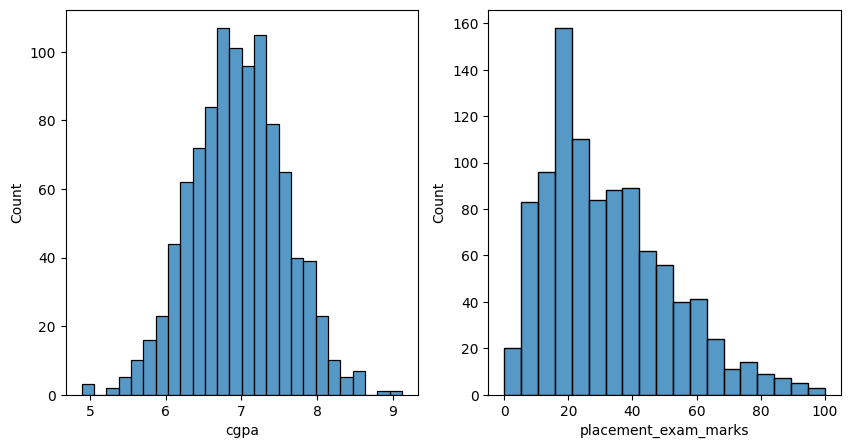

In [29]:
plt .figure(figsize = (10,5))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'])

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'])

plt.show()

In [30]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [31]:
# Finding the boundary values
print("Highest value", df['cgpa'].mean() + 3 * df['cgpa'].std())
print("Lowest value", df['cgpa'].mean() - 3 * df['cgpa'].std())

Highest value 8.808933625397168
Lowest value 5.113546374602832


In [39]:
# Fiding the outliers based on cgpa

df[(df['cgpa']>8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [43]:
# Trimming the outliers
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa']>5.11)]

In [44]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [45]:
new_df.describe()

,cgpa,placement_exam_marks,placed
count,995.000000,995.000000,995.000000
mean,6.963357,32.188945,0.487437
std,0.600082,19.130298,0.500094
min,5.230000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.365000,44.000000,1.000000
max,8.620000,100.000000,1.000000


In [47]:
# Calculating the Z-score

df['cgpa_Z_Score'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [48]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [50]:
# Finding the outliers using Z_Score

df[(df['cgpa_Z_Score']>3) | (df['cgpa_Z_Score'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [53]:
# Trimming

new_df1 = df[(df['cgpa_Z_Score'] > -3) & (df['cgpa_Z_Score'] < 3)]

In [54]:
new_df1.head()

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [56]:
new_df1.shape

(995, 4)

## Capping

In [57]:
# Capping -->  Capping refers to the replacing the outliers with the boundary/max value.

In [62]:
df

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [63]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [ ]:
upper_limit

np.float64(8.808933625397168)

In [65]:
lower_limit

np.float64(5.113546374602832)

In [66]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit, 
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [67]:
df

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


In [68]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_Z_Score
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00


In [69]:
# Outliers are removed